## Part 4 Putting it all Together  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mwclient import Site
from mwviews.api import PageviewsClient

/Users/chinazaaham-neze/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
kdramas = pd.read_csv('kdramas_2023.csv')
print(kdramas.shape)
kdramas.head()

(213, 18)


,Unnamed: 0,Year,Title_English,Episodes,Popularity,Aired,Aired On,Duration,Genres,Tags,Summary,Title_Korean,Also Known As,Content Rating,Score_Votes,Score,Ranked,Watchers
0,0,2023,High Cookie (2023),20,1638,"Oct 23, 2023 - Nov 23, 2023",NaN,34 min.,"['Thriller', 'Mystery', 'Youth', 'Fantasy']","['Bully Supporting Character', 'Student Suppor...",A teen fantasy thriller drama that tells the s...,하이쿠키,"Hai Kuki , Haikuki , Hi Cookie , Привет, печен...",18+ Restricted (violence & profanity),2440,7.3,8082,15709
1,1,2023,Strangers Again (2023),12,1515,"Jan 18, 2023 - Feb 23, 2023","Wednesday, Thursday",1 hr. 10 min.,"['Law', 'Romance', 'Drama']","[""Bickering Mains' Relationship"", 'Ex-spouse R...","Divorce lawyer Oh Ha Ra, known as the “goddess...",남이 될 수 있을까?,"Can I Be Someone Else , Can I Be Someone Else?...",15+ - Teens 15 or older,5187,7.2,9766,17025
2,2,2023,Hello! This Is Starbucks (2023),19,99999,"Jun 20, 2023 - Jul 27, 2023","Tuesday, Wednesday, Thursday",1 min.,['Life'],"['Café Setting', 'Short Length Series', 'Web S...",This web drama deals with a theme based on the...,안녕하세요! 스타벅스입니다,Annyeonghaseyo! Seutabeokseuibnida,Not Yet Rated,5,5.9,99999,105
3,3,2023,Adult Kids (2023),8,9473,"Jun 19, 2023 - Aug 7, 2023",Monday,10 min.,"['Life', 'Drama']","['Female Centered Plot', 'Short Length Series'...",A hyper-realistic drama depicting the daily li...,어른애들,"Crianças Adultas , Eoreunaedeul , The Adult Li...",Not Yet Rated,181,7.1,10086,1250
4,4,2023,My Demon (2023),16,40,"Nov 24, 2023 - Jan 20, 2024","Friday, Saturday",1 hr. 6 min.,"['Action', 'Comedy', 'Romance', 'Fantasy']","['Demon Male Lead', 'Supernatural', 'Heiress F...",Do Do Hee is the successor of the Future Group...,마이데몬,"Demonul Șarmant , Maidemon , Meu Demônio Favor...",15+ - Teens 15 or older,97628,8.3,1177,165957


In [4]:
top = kdramas.sort_values('Watchers', ascending=False).head(20)
top = top[top['Title_English'] != 'Bloodhounds (2023)']
top[['Title_English', 'Watchers']]

,Title_English,Watchers
21,Twinkling Watermelon (2023),208093
4,My Demon (2023),165957
34,King the Land (2023),159534
50,The Glory Part 2 (2023),126515
62,Moving (2023),117101
129,Death's Game (2023),103733
193,Welcome to Samdal-ri (2023),100774
92,See You in My 19th Life (2023),99525
65,Destined with You (2023),92576
155,The Good Bad Mother (2023),90431


In [5]:
titles = [t.replace(' (2023)', '') for t in top['Title_English']]

fixes = {
    'The Glory Part 2': 'The Glory (TV series)',
    'Moving': 'Moving (South Korean TV series)',
    'Celebrity': 'Celebrity (South Korean TV series)',
    'Love to Hate You': 'Love to Hate You (TV series)',
}
titles = [fixes.get(t, t) for t in titles]
titles

['Twinkling Watermelon',
 'My Demon',
 'King the Land',
 'The Glory (TV series)',
 'Moving (South Korean TV series)',
 "Death's Game",
 'Welcome to Samdal-ri',
 'See You in My 19th Life',
 'Destined with You',
 'The Good Bad Mother',
 'My Lovely Liar',
 'Crash Course in Romance',
 'Love to Hate You (TV series)',
 'Perfect Marriage Revenge',
 'A Time Called You',
 'Doona!',
 'Celebrity (South Korean TV series)',
 'Daily Dose of Sunshine',
 'Gyeongseong Creature']

In [6]:
site = Site('en.wikipedia.org')

for t in titles:
    page = site.pages[t]
    print(t, "| exists:", page.exists, "| redirect:", page.redirect)

Twinkling Watermelon | exists: True | redirect: False
My Demon | exists: True | redirect: False
King the Land | exists: True | redirect: False
The Glory (TV series) | exists: True | redirect: False
Moving (South Korean TV series) | exists: True | redirect: False
Death's Game | exists: True | redirect: False
Welcome to Samdal-ri | exists: True | redirect: False
See You in My 19th Life | exists: True | redirect: False
Destined with You | exists: True | redirect: False
The Good Bad Mother | exists: True | redirect: False
My Lovely Liar | exists: True | redirect: False
Crash Course in Romance | exists: True | redirect: False
Love to Hate You (TV series) | exists: True | redirect: False
Perfect Marriage Revenge | exists: True | redirect: False
A Time Called You | exists: True | redirect: False
Doona! | exists: True | redirect: False
Celebrity (South Korean TV series) | exists: True | redirect: False
Daily Dose of Sunshine | exists: True | redirect: False
Gyeongseong Creature | exists: True 

In [8]:
client = PageviewsClient(user_agent="CS315 student project")
data = client.article_views('en.wikipedia', titles,
                            start='20220601', end='20240601')

In [9]:
views = pd.DataFrame.from_dict(data, orient='index')
views = views[[t.replace(' ', '_') for t in titles]]      # keep the Watchers order
views.columns = titles
views.head()

,Twinkling Watermelon,My Demon,King the Land,The Glory (TV series),Moving (South Korean TV series),Death's Game,Welcome to Samdal-ri,See You in My 19th Life,Destined with You,The Good Bad Mother,My Lovely Liar,Crash Course in Romance,Love to Hate You (TV series),Perfect Marriage Revenge,A Time Called You,Doona!,Celebrity (South Korean TV series),Daily Dose of Sunshine,Gyeongseong Creature
2022-06-01,NaN,NaN,NaN,NaN,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,134,NaN,NaN,NaN,NaN
2022-06-02,NaN,NaN,NaN,NaN,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,128,NaN,NaN,NaN,NaN
2022-06-03,NaN,NaN,NaN,NaN,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127,NaN,NaN,NaN,NaN
2022-06-04,NaN,NaN,NaN,NaN,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,154,NaN,NaN,NaN,NaN
2022-06-05,NaN,NaN,NaN,NaN,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,137,NaN,NaN,NaN,NaN


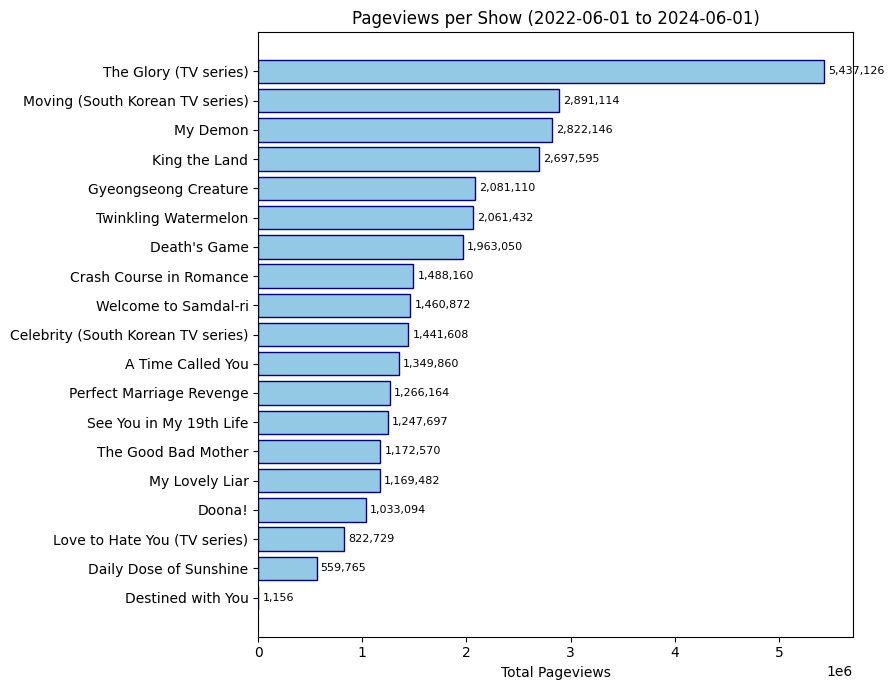

In [10]:
totals = views.sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(totals.index, totals.values, color='#94c9e6', edgecolor='navy')
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in totals.values], padding=3, fontsize=8)
ax.set_title("Pageviews per Show (2022-06-01 to 2024-06-01)")
ax.set_xlabel("Total Pageviews")
plt.tight_layout()
plt.show()

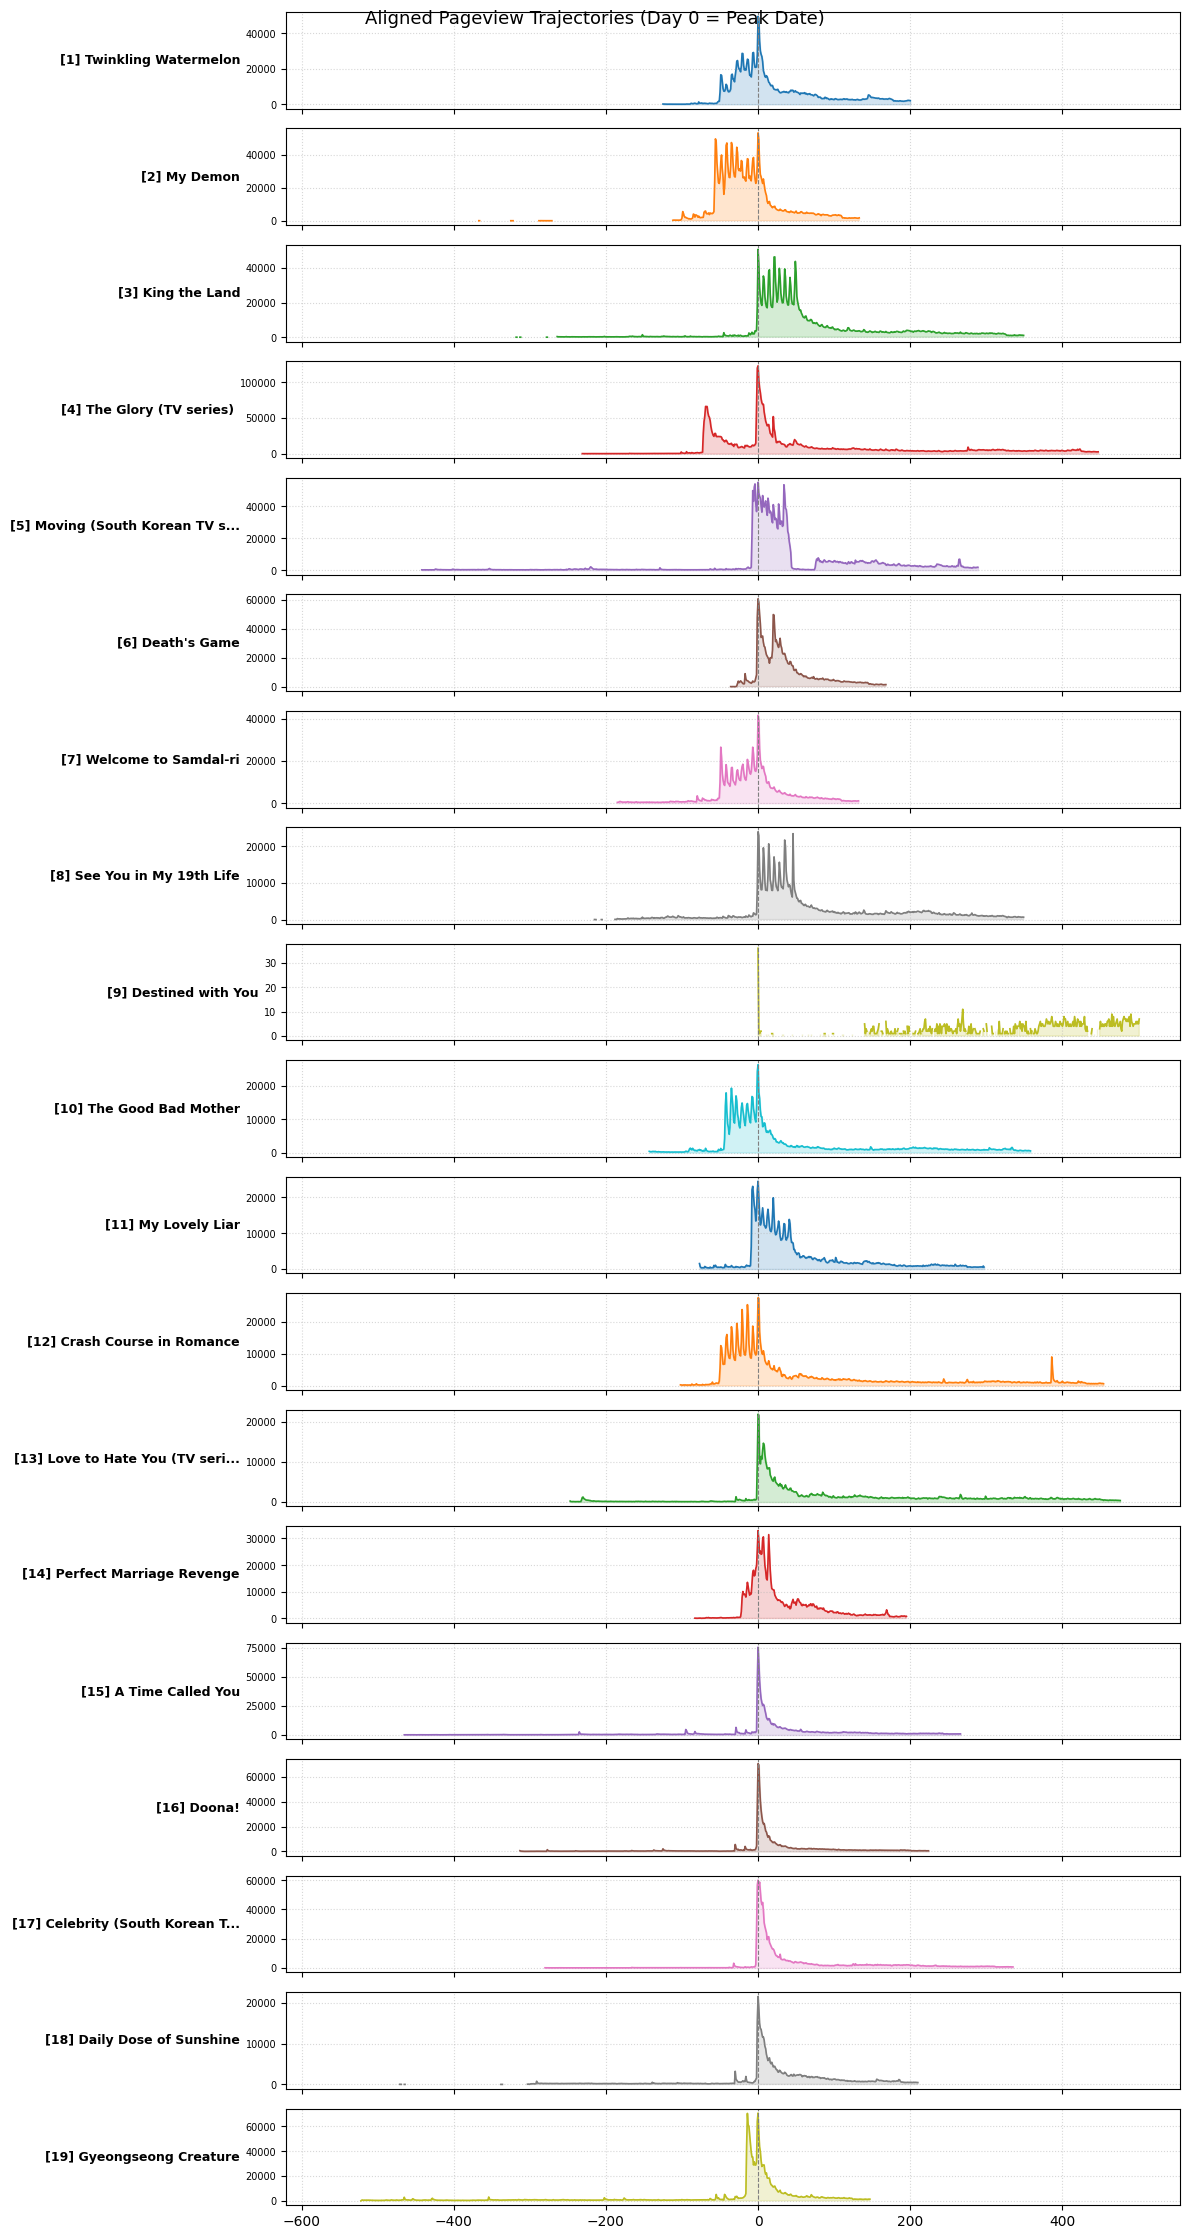

In [ ]:
fig, axes = plt.subplots(len(titles), 1, figsize=(12, 1.2 * len(titles)), sharex=True)
colors = plt.cm.tab10.colors

for i, (ax, show) in enumerate(zip(axes, titles)):
    series = views[show]
    peak = series.idxmax()   
    days = (series.index - peak).days  
    color = colors[i % 10]

    ax.plot(days, series.values, color=color, linewidth=1.2)
    ax.fill_between(days, series.values, color=color, alpha=0.2)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.grid(linestyle=':', alpha=0.5)

    label = show if len(show) <= 25 else show[:25] + '...'
    ax.set_ylabel(f"[{i+1}] {label}", rotation=0, ha='right', va='center',
                  fontsize=9, fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle("Aligned Pageview Trajectories (Day 0 = Peak Date)", fontsize=13)
plt.tight_layout()
plt.show()